# Bank Customer Churn: Class Imbalance Methods

Disclaimer: No Hyperparameter tuning added to this project. I just wanted to show how different Data Imbalance models perform in "one" Logistic Regression Algo. 

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours

## Load data

In [5]:
df = pd.read_csv("../data/Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 12)

In [7]:
df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

## Target balance

In [8]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df["churn"].value_counts(normalize=True) * 100

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

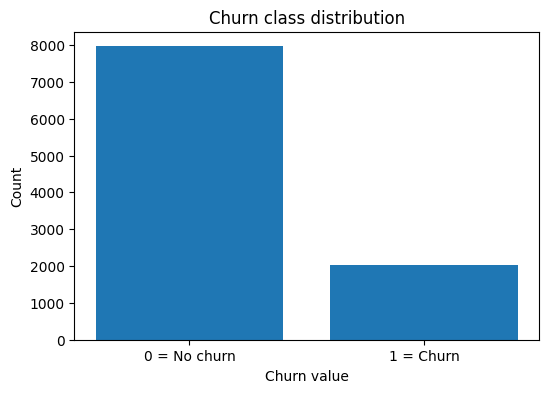

In [10]:
class_counts = df["churn"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Churn class distribution")
plt.xlabel("Churn value")
plt.ylabel("Count")
plt.xticks([0, 1], ["0 = No churn", "1 = Churn"])
plt.show()

## Prepare X and y

In [11]:
X = df.drop(["customer_id", "churn"], axis=1)
y = df["churn"]

X = pd.get_dummies(X, columns=["country", "gender"], drop_first=True)

X.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((8000, 11), (2000, 11))

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
all_results = []

## Baseline Logistic Regression

In [15]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["Baseline", acc, precision, recall, f1])

accuracy: 0.808
precision: 0.5891472868217055
recall: 0.18673218673218672
f1: 0.2835820895522388

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



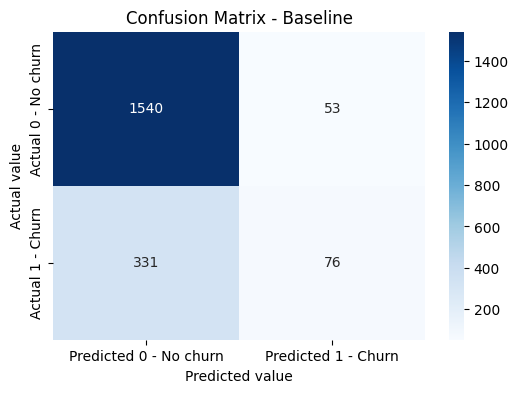

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - Baseline")
plt.show()

## RandomOverSampler

In [17]:
ros = RandomOverSampler(random_state=42)

X_ros, y_ros = ros.fit_resample(X_train_scaled, y_train)

pd.Series(y_ros).value_counts()

churn
1    6370
0    6370
Name: count, dtype: int64

In [18]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_ros, y_ros)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["RandomOverSampler", acc, precision, recall, f1])

accuracy: 0.716
precision: 0.3910690121786198
recall: 0.7100737100737101
f1: 0.5043630017452007

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1593
           1       0.39      0.71      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



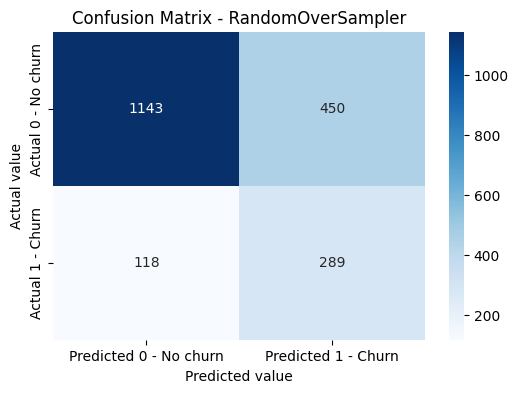

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - RandomOverSampler")
plt.show()

## SMOTE

In [20]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

pd.Series(y_smote).value_counts()

churn
1    6370
0    6370
Name: count, dtype: int64

In [21]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_smote, y_smote)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["SMOTE", acc, precision, recall, f1])

accuracy: 0.7155
precision: 0.38904109589041097
recall: 0.6977886977886978
f1: 0.4995602462620932

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



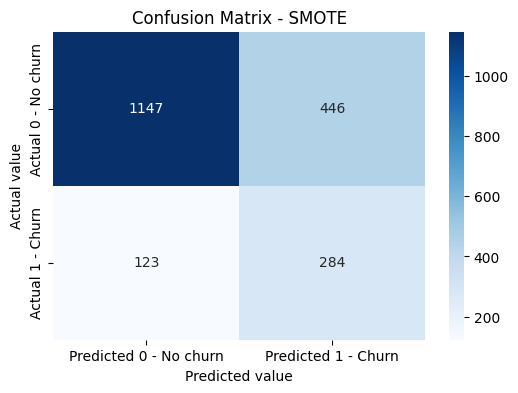

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - SMOTE")
plt.show()

## ADASYN

In [23]:
adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

pd.Series(y_adasyn).value_counts()

churn
1    6482
0    6370
Name: count, dtype: int64

In [24]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_adasyn, y_adasyn)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["ADASYN", acc, precision, recall, f1])

accuracy: 0.6905
precision: 0.3681592039800995
recall: 0.7272727272727273
f1: 0.4888521882741536

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1593
           1       0.37      0.73      0.49       407

    accuracy                           0.69      2000
   macro avg       0.64      0.70      0.63      2000
weighted avg       0.80      0.69      0.72      2000



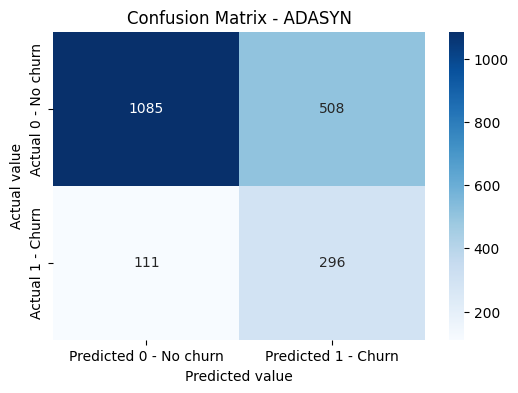

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - ADASYN")
plt.show()

## RandomUnderSampler

In [26]:
rus = RandomUnderSampler(random_state=42)

X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)

pd.Series(y_rus).value_counts()

churn
0    1630
1    1630
Name: count, dtype: int64

In [27]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_rus, y_rus)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["RandomUnderSampler", acc, precision, recall, f1])

accuracy: 0.7035
precision: 0.37890625
recall: 0.714987714987715
f1: 0.49531914893617024

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1593
           1       0.38      0.71      0.50       407

    accuracy                           0.70      2000
   macro avg       0.64      0.71      0.64      2000
weighted avg       0.80      0.70      0.73      2000



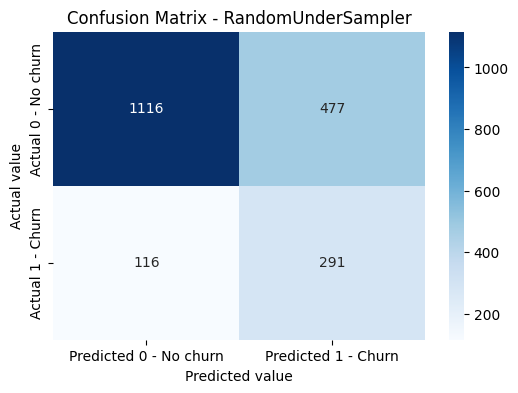

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - RandomUnderSampler")
plt.show()

## EditedNearestNeighbours

In [29]:
enn = EditedNearestNeighbours()

X_enn, y_enn = enn.fit_resample(X_train_scaled, y_train)

pd.Series(y_enn).value_counts()

churn
0    4528
1    1630
Name: count, dtype: int64

In [30]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_enn, y_enn)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["EditedNearestNeighbours", acc, precision, recall, f1])

accuracy: 0.788
precision: 0.47745358090185674
recall: 0.44226044226044225
f1: 0.45918367346938777

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1593
           1       0.48      0.44      0.46       407

    accuracy                           0.79      2000
   macro avg       0.67      0.66      0.66      2000
weighted avg       0.78      0.79      0.78      2000



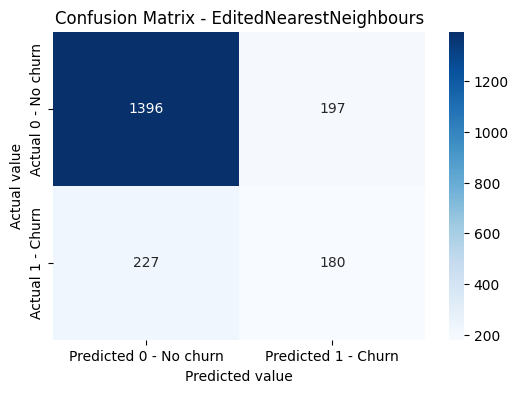

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - EditedNearestNeighbours")
plt.show()

## class_weight="balanced"

In [32]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["class_weight balanced", acc, precision, recall, f1])

accuracy: 0.7135
precision: 0.38722826086956524
recall: 0.7002457002457002
f1: 0.49868766404199477

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



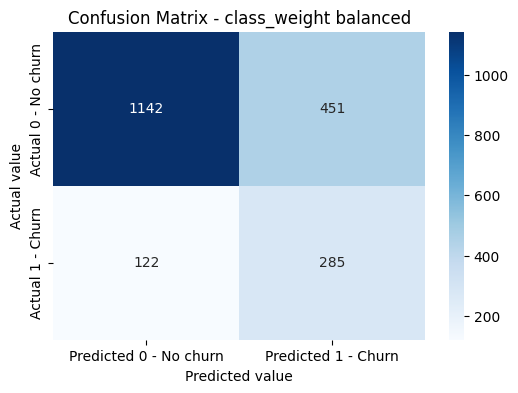

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - class_weight balanced")
plt.show()

## Custom class weights

In [34]:
class_weights = {
    0: 1,
    1: 10
}

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=class_weights
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("accuracy:", acc)
print("precision:", precision)
print("recall:", recall)
print("f1:", f1)
print()
print(classification_report(y_test, y_pred))

all_results.append(["class_weight custom 1:10", acc, precision, recall, f1])

accuracy: 0.46
precision: 0.2635277582572031
recall: 0.9213759213759214
f1: 0.4098360655737705

              precision    recall  f1-score   support

           0       0.94      0.34      0.50      1593
           1       0.26      0.92      0.41       407

    accuracy                           0.46      2000
   macro avg       0.60      0.63      0.46      2000
weighted avg       0.81      0.46      0.48      2000



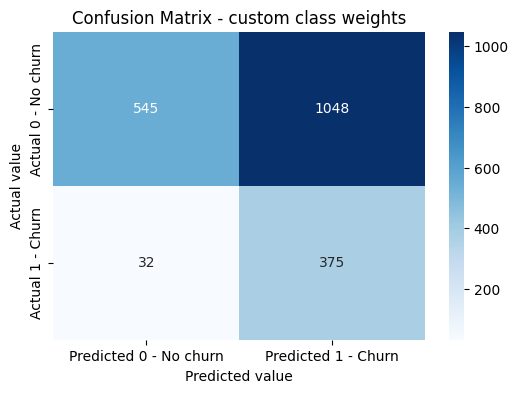

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0 - No churn", "Predicted 1 - Churn"],
    yticklabels=["Actual 0 - No churn", "Actual 1 - Churn"]
)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix - custom class weights")
plt.show()

## Final comparison

In [36]:
results_df = pd.DataFrame(
    all_results,
    columns=["method", "accuracy", "precision", "recall", "f1"]
)

results_df.sort_values("f1", ascending=False)

,method,accuracy,precision,recall,f1
1,RandomOverSampler,0.7160,0.391069,0.710074,0.504363
2,SMOTE,0.7155,0.389041,0.697789,0.499560
6,class_weight balanced,0.7135,0.387228,0.700246,0.498688
4,RandomUnderSampler,0.7035,0.378906,0.714988,0.495319
3,ADASYN,0.6905,0.368159,0.727273,0.488852
5,EditedNearestNeighbours,0.7880,0.477454,0.442260,0.459184
7,class_weight custom 1:10,0.4600,0.263528,0.921376,0.409836
0,Baseline,0.8080,0.589147,0.186732,0.283582
